# Usage

You first need to run par.sh in experiments (from the build folder) to collect the data for each binary.
The script needs to be edited for each binary name, then the results moved into place.
The nomenclature is:

- triangle[RF]/files.    : the PIDP style model (simplest). XF or RF
- triangle2[RF]/files.   : the intermediate style (DDO looking with simple code for bound)
- triangle3[RF]/files.   : the closest to DDO for everything.

Each folder should contain one file named like: `triangle3.relaxed-first` or `triangle3.restricted-first`. It is just the concatenation of all the 
other files. 

## Objective
We used the PIDP objective on everything.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import regex as re

# Parsing traces into dataframes

In [110]:
flt = r'\d*\.*\d*e?\+?-?\d*'
error_type = lambda e,t: lambda x: e if x is None else t(x)
i32 = error_type(None, np.int32)
f64 = error_type(None, np.float64)
f64_TO = error_type('T.O.', np.float64)

def didp_to_df(fname,dir='.',ext='.dat'):
    patterns = [
        r'(\S*) w:(\S*)\s.*',
        r'T.O.|(\S*) (\S*) (\S*) (\S*)'
    ]
    labels_list = [['Bench','Width'],
                   ['Opt','nodes1','nodes2','Proof Time']
                  ]
    types_list = [[str,str],
                  [i32,i32,i32,f64_TO]]
    csv = {}
    with open(f'{dir}/{fname}{ext}') as f:  
        i = 0
        p = False
        for line in f.readlines():
            pattern = patterns[i]
            labels = labels_list[i]
            types = types_list[i]
            i = (i+1) % len(patterns)
            match = re.search(pattern, line)
            if match is None: continue
            groups = match.groups()
            if len(groups) == 0:
                groups = [None] * len(labels)
            for label, match, convert in zip(labels, groups, types):
                if label is None or convert is None: continue
                match = convert(match)                
                if label in csv: csv[label].append(match)
                else: csv[label] = [match]

    return pd.DataFrame.from_dict(csv, orient='index').transpose()    
    
def experiment_to_df(fname, dir='.', ext='.dat', patterns=None, labels_list=None, types_list=None):
    if patterns is None:
        pattern1 = r'(\S*) w:(\S*)\s.*'
        pattern2 = r'T.O.|Done\(\d*\):($flt)\s+#nodes:($flt)\/($flt)\s+P\/D:($flt)\/($flt)\s+Time:($flt)\/($flt)s\s+LIM\?:($flt)\s+Seen:($flt)'.replace(r'$flt', flt)
        patterns = [pattern1, pattern2]
    if labels_list is None:
        labels1 = ['Bench', 'Width']
        labels2 = ['Opt', 'nodes1', 'nodes2', 'P', 'D', 'Opt Time', 'Proof Time', None, None]
        labels_list = [labels1, labels2]
    if types_list is None:
        type1 = [str, np.int32]
        type2 = [f64, i32, i32, i32, i32, f64_TO, f64_TO, None, None]
        types_list = [type1, type2]

    csv = {}
    with open(f'{dir}/{fname}{ext}') as f:  
        i = 0
        p = False
        for line in f.readlines():
            pattern = patterns[i]
            labels = labels_list[i]
            types = types_list[i]
            i = (i+1) % len(patterns)

            match = re.search(pattern, line)
            if match is None: continue
            groups = match.groups()

            if len(groups) == 0:
                groups = [None] * len(labels)

            for label, match, convert in zip(labels, groups, types):
                if label is None or convert is None: continue

                match = convert(match)
                
                if label in csv: csv[label].append(match)
                else: csv[label] = [match]

    return pd.DataFrame.from_dict(csv, orient='index').transpose()

In [98]:
def experiment_to_df_tsptw(fname, patterns=None, labels_list=None, types_list=None, scale_opt=None, opt_name='Opt'):
    exp = experiment_to_df(fname, patterns=patterns, labels_list=labels_list, types_list=types_list)  
    if scale_opt is not None: exp[opt_name] /= scale_opt
    return exp

def didp_to_df_tsptw(fname,scale_opt=None, opt_name='Opt'):
    exp = didp_to_df(fname)    
    if scale_opt is not None: exp[opt_name] /= scale_opt
    return exp

In [5]:
import os
print(os.getcwd())

/Volumes/HomeX/ldm/work/CODD/experiments


# loading traces

In [6]:
exp1 = experiment_to_df_tsptw('../build/triangle3/triangle3.relaxed-first', scale_opt=10000.0); exp1['Bench'] = exp1['Bench'].str.split('/').str[-2:].str.join('/')

In [10]:
exp1Clean = exp1.dropna()
with pd.option_context('display.max_rows', None,):
    display(exp1Clean)

,Bench,Width,Opt,nodes1,nodes2,P,D,Opt Time,Proof Time
0,AFG/rbg010a.tw,128,671.0,1,1,0,0,0.003,0.003
1,AFG/rbg010a.tw,256,671.0,1,1,0,0,0.003,0.003
2,AFG/rbg010a.tw,1024,671.0,1,1,0,0,0.003,0.003
3,AFG/rbg016a.tw,128,938.0,1,1,0,0,0.003,0.004
4,AFG/rbg016a.tw,256,938.0,1,1,0,0,0.003,0.004
5,AFG/rbg016a.tw,1024,938.0,1,1,0,0,0.003,0.004
6,AFG/rbg016b.tw,128,1304.0,967,967,133,443,0.014,0.142
7,AFG/rbg016b.tw,256,1304.0,485,485,96,165,0.021,0.103
8,AFG/rbg016b.tw,1024,1304.0,1,1,0,0,0.037,0.037
9,AFG/rbg017.2.tw,128,852.0,8239,8239,793,2587,0.017,1.911


In [17]:
exp2 = experiment_to_df_tsptw('../build/triangle3RF/triangle3.restricted-first', scale_opt=10000.0); exp2['Bench'] = exp2['Bench'].str.split('/').str[-2:].str.join('/')
exp2Clean = exp2.dropna()
with pd.option_context('display.max_rows', None,):
    display(exp2Clean)

,Bench,Width,Opt,nodes1,nodes2,P,D,Opt Time,Proof Time
0,AFG/rbg010a.tw,128,671.0,1,1,0,0,0.002,0.002
1,AFG/rbg010a.tw,256,671.0,1,1,0,0,0.002,0.002
2,AFG/rbg010a.tw,1024,671.0,1,1,0,0,0.002,0.002
3,AFG/rbg016a.tw,128,938.0,1,1,0,0,0.003,0.003
4,AFG/rbg016a.tw,256,938.0,1,1,0,0,0.003,0.003
5,AFG/rbg016a.tw,1024,938.0,1,1,0,0,0.003,0.003
6,AFG/rbg016b.tw,128,1304.0,19,19,0,150,0.004,0.078
7,AFG/rbg016b.tw,256,1304.0,1,1,0,10,0.006,0.012
8,AFG/rbg016b.tw,1024,1304.0,1,1,0,0,0.008,0.008
9,AFG/rbg017.2.tw,128,852.0,145,145,0,383,0.003,1.953


In [18]:
exp3 = experiment_to_df_tsptw('../build/triangle2/triangle2.relaxed-first', scale_opt=10000.0); exp3['Bench'] = exp3['Bench'].str.split('/').str[-2:].str.join('/')
exp3Clean = exp3.dropna()
with pd.option_context('display.max_rows', None,):
    display(exp3Clean)

,Bench,Width,Opt,nodes1,nodes2,P,D,Opt Time,Proof Time
0,AFG/rbg010a.tw,128,671.0,1,1,0,0,0.003,0.003
1,AFG/rbg010a.tw,256,671.0,1,1,0,0,0.003,0.003
2,AFG/rbg010a.tw,1024,671.0,1,1,0,0,0.002,0.002
3,AFG/rbg016a.tw,128,938.0,1,1,0,0,0.002,0.003
4,AFG/rbg016a.tw,256,938.0,1,1,0,0,0.003,0.003
5,AFG/rbg016a.tw,1024,938.0,1,1,0,0,0.003,0.003
6,AFG/rbg016b.tw,128,1304.0,994,994,155,416,0.012,0.098
7,AFG/rbg016b.tw,256,1304.0,495,495,91,164,0.018,0.071
8,AFG/rbg016b.tw,1024,1304.0,1,1,0,0,0.031,0.031
9,AFG/rbg017.2.tw,128,852.0,6354,6354,565,1932,0.014,1.15


In [19]:
exp4 = experiment_to_df_tsptw('../build/triangle2RF/triangle2.restricted-first', scale_opt=10000.0); exp3['Bench'] = exp3['Bench'].str.split('/').str[-2:].str.join('/')
exp4Clean = exp4.dropna()
with pd.option_context('display.max_rows', None,):
    display(exp4Clean)

,Bench,Width,Opt,nodes1,nodes2,P,D,Opt Time,Proof Time
0,../data/tsptw/AFG/rbg010a.tw,128,671.0,1,1,0,0,0.002,0.002
1,../data/tsptw/AFG/rbg010a.tw,256,671.0,1,1,0,0,0.003,0.003
2,../data/tsptw/AFG/rbg010a.tw,1024,671.0,1,1,0,0,0.003,0.003
3,../data/tsptw/AFG/rbg016a.tw,128,938.0,1,1,0,0,0.003,0.003
4,../data/tsptw/AFG/rbg016a.tw,256,938.0,1,1,0,0,0.003,0.003
5,../data/tsptw/AFG/rbg016a.tw,1024,938.0,1,1,0,0,0.003,0.003
6,../data/tsptw/AFG/rbg016b.tw,128,1304.0,16,16,0,134,0.004,0.062
7,../data/tsptw/AFG/rbg016b.tw,256,1304.0,1,1,0,16,0.007,0.011
8,../data/tsptw/AFG/rbg016b.tw,1024,1304.0,1,1,0,0,0.009,0.009
9,../data/tsptw/AFG/rbg017.2.tw,128,852.0,115,115,0,298,0.004,0.98


In [25]:
exp5 = experiment_to_df_tsptw('../build/triangle/triangle.relaxed-first', scale_opt=10000.0); exp3['Bench'] = exp3['Bench'].str.split('/').str[-2:].str.join('/')
exp5Clean = exp5.dropna()
with pd.option_context('display.max_rows', None,):
    display(exp5Clean)

,Bench,Width,Opt,nodes1,nodes2,P,D,Opt Time,Proof Time
0,../data/tsptw/AFG/rbg010a.tw,128,671.0,1,1,0,0,0.003,0.003
1,../data/tsptw/AFG/rbg010a.tw,256,671.0,1,1,0,0,0.002,0.003
2,../data/tsptw/AFG/rbg010a.tw,1024,671.0,1,1,0,0,0.003,0.003
3,../data/tsptw/AFG/rbg016a.tw,128,938.0,1,1,0,0,0.003,0.003
4,../data/tsptw/AFG/rbg016a.tw,256,938.0,1,1,0,0,0.003,0.003
5,../data/tsptw/AFG/rbg016a.tw,1024,938.0,1,1,0,0,0.003,0.003
6,../data/tsptw/AFG/rbg016b.tw,128,1304.0,1326,1326,165,932,0.005,0.071
7,../data/tsptw/AFG/rbg016b.tw,256,1304.0,593,593,101,318,0.01,0.05
8,../data/tsptw/AFG/rbg016b.tw,1024,1304.0,1,1,0,0,0.024,0.024
9,../data/tsptw/AFG/rbg017.2.tw,128,852.0,13182,13182,1385,7354,0.006,2.345


In [46]:
exp6 = experiment_to_df_tsptw('../build/triangleRF/triangle.restricted-first', scale_opt=10000.0); exp3['Bench'] = exp3['Bench'].str.split('/').str[-2:].str.join('/')
exp6Clean = exp6.dropna()
with pd.option_context('display.max_rows', None,):
    display(exp6Clean)

,Bench,Width,Opt,nodes1,nodes2,P,D,Opt Time,Proof Time
0,../data/tsptw/AFG/rbg010a.tw,128,671.0,1,1,0,0,0.003,0.003
1,../data/tsptw/AFG/rbg010a.tw,256,671.0,1,1,0,0,0.003,0.003
2,../data/tsptw/AFG/rbg010a.tw,1024,671.0,1,1,0,0,0.002,0.002
3,../data/tsptw/AFG/rbg016a.tw,128,938.0,1,1,0,0,0.003,0.003
4,../data/tsptw/AFG/rbg016a.tw,256,938.0,1,1,0,0,0.003,0.003
5,../data/tsptw/AFG/rbg016a.tw,1024,938.0,1,1,0,0,0.003,0.003
6,../data/tsptw/AFG/rbg016b.tw,128,1304.0,22,22,0,144,0.004,0.043
7,../data/tsptw/AFG/rbg016b.tw,256,1304.0,1,1,0,16,0.006,0.01
8,../data/tsptw/AFG/rbg016b.tw,1024,1304.0,1,1,0,0,0.007,0.007
9,../data/tsptw/AFG/rbg017.2.tw,128,852.0,287,287,0,447,0.003,0.729


In [114]:
exp4['Bench']=exp4['Bench'].str.replace('../data/tsptw/','')
exp5['Bench']=exp5['Bench'].str.replace('../data/tsptw/','')
exp6['Bench']=exp6['Bench'].str.replace('../data/tsptw/','')

# Frames

## exp1/exp2 
triangle3 Relaxed and triangle3 Restricted (Closest to DDO, except the objective function)
## exp3/exp4
triangle2 Relaxed and triangle2 Restricted (Our version with states in the style of DDO, simple bound)
## exp5/exp6 
triangle Relaxed and triangle Restricted (closest model to DIDP)

In [27]:
len(exp1Clean),len(exp2Clean),len(exp3Clean),len(exp4Clean),len(exp5Clean),len(exp6Clean)

(710, 743, 687, 728, 705, 745)

# Observations

## Restricted 
Interestingly enough, the Restricted does better (in # of benchmarks solved within 300s) than relaxed. Even though there are no heuristics at the moment to try and take advantage. It's the exact same model, just another engine.

## DDO style vs DIDP style
exp5/exp6 are the models closest to DIDP (simple state, simple merging) and they seem to do quite well in restricted.
For relaxed, the best approach is DDO style. Note that the difference at the 5 minutes mark is not large: 710 vs. 705. (and inverted 743 vs. 745 for restricted).

## DIDP results needed

I still need to collate those on ilyin.

# DIDP Experiments

This is what collates the results from runnintg DIDP on everything.

In [147]:
didp = didp_to_df_tsptw('../build/didp',scale_opt=10000.0)
didp['Bench'] = didp['Bench'].str.replace('tsptw/','')
didp['Bench'] = didp['Bench'].str.replace('.yaml','')

In [148]:
didpClean = didp.dropna()
with pd.option_context('display.max_rows', None,):
    display(didpClean)

,Bench,Width,Opt,nodes1,nodes2,Proof Time
0,AFG/rbg010a.tw,_,671.0,347,436,0.000732
1,AFG/rbg016a.tw,_,938.0,671,831,0.002034
2,AFG/rbg016b.tw,_,1304.0,7813,10390,0.01879
3,AFG/rbg017.2.tw,_,852.0,140148,213796,0.414247
4,AFG/rbg017a.tw,_,4296.0,1271,1607,0.003276
5,AFG/rbg017.tw,_,893.0,4196,5697,0.008497
6,AFG/rbg019a.tw,_,1262.0,169,193,0.000582
7,AFG/rbg019b.tw,_,1866.0,18004,23778,0.060373
8,AFG/rbg019c.tw,_,4536.0,8458,11110,0.024934
9,AFG/rbg019d.tw,_,1356.0,1171,1420,0.003192


# Combining

This pulls all experiments together to do comparisons / plots.

In [151]:
exp1.columns = exp1Clean.columns
exp2.columns = exp2Clean.columns
exp3.columns = exp3Clean.columns
exp4.columns = exp4Clean.columns
exp5.columns = exp5Clean.columns
exp6.columns = exp6Clean.columns
didp.columns = didpClean.columns
exp1.columns

Index(['Bench', 'Width', 'Opt', 'nodes1', 'nodes2', 'P', 'D', 'Opt Time',
       'Proof Time'],
      dtype='object')

In [152]:
L = 0; R = 1
suffixes = ('_codd3_xf', '_codd3_rf', '_codd2_xf', '_codd2_rf', '_codd1_xf','_codd1_rf','_didp')
exp1.columns = exp1.columns.map(lambda name: name+suffixes[0] if name not in ('Width', 'Bench') else name)
exp2.columns = exp2.columns.map(lambda name: name+suffixes[1] if name not in ('Width', 'Bench') else name)
exp3.columns = exp3.columns.map(lambda name: name+suffixes[2] if name not in ('Width', 'Bench') else name)
exp4.columns = exp4.columns.map(lambda name: name+suffixes[3] if name not in ('Width', 'Bench') else name)
exp5.columns = exp5.columns.map(lambda name: name+suffixes[4] if name not in ('Width', 'Bench') else name)
exp6.columns = exp6.columns.map(lambda name: name+suffixes[5] if name not in ('Width', 'Bench') else name)
didp.columns = didp.columns.map(lambda name: name+suffixes[6] if name not in ('Width', 'Bench') else name)

In [153]:
didp.columns

Index(['Bench', 'Width', 'Opt_didp', 'nodes1_didp', 'nodes2_didp',
       'Proof Time_didp'],
      dtype='object')

In [76]:
exp4.columns

Index(['Bench', 'Width', 'Opt_codd2_rf', 'nodes1_codd2_rf', 'nodes2_codd2_rf',
       'P_codd2_rf', 'D_codd2_rf', 'Opt Time_codd2_rf', 'Proof Time_codd2_rf'],
      dtype='object')

In [77]:
exp5.columns

Index(['Bench', 'Width', 'Opt_codd1_xf', 'nodes1_codd1_xf', 'nodes2_codd1_xf',
       'P_codd1_xf', 'D_codd1_xf', 'Opt Time_codd1_xf', 'Proof Time_codd1_xf'],
      dtype='object')

In [167]:
merge = pd.merge(exp1, exp2, on=['Bench', 'Width'], how='inner').merge(exp3, on=['Bench', 'Width'], how='inner').merge(exp4, on=['Bench','Width'], how='inner').merge(exp5, on=['Bench', 'Width'], how='inner').merge(exp6, on=['Bench', 'Width'], how='inner')

In [168]:
final = merge #merge[merge["Bench"].isin(triangular)]
#final[~final.notna()] = 'T.O.'
final

,Bench,Width,Opt_codd3_xf,nodes1_codd3_xf,nodes2_codd3_xf,P_codd3_xf,D_codd3_xf,Opt Time_codd3_xf,Proof Time_codd3_xf,Opt_codd3_rf,...,D_codd1_xf,Opt Time_codd1_xf,Proof Time_codd1_xf,Opt_codd1_rf,nodes1_codd1_rf,nodes2_codd1_rf,P_codd1_rf,D_codd1_rf,Opt Time_codd1_rf,Proof Time_codd1_rf
0,AFG/rbg010a.tw,128,671.0,1,1,0,0,0.003,0.003,671.0,...,0,0.003,0.003,671.0,1,1,0,0,0.003,0.003
1,AFG/rbg010a.tw,256,671.0,1,1,0,0,0.003,0.003,671.0,...,0,0.002,0.003,671.0,1,1,0,0,0.003,0.003
2,AFG/rbg010a.tw,1024,671.0,1,1,0,0,0.003,0.003,671.0,...,0,0.003,0.003,671.0,1,1,0,0,0.002,0.002
3,AFG/rbg016a.tw,128,938.0,1,1,0,0,0.003,0.004,938.0,...,0,0.003,0.003,938.0,1,1,0,0,0.003,0.003
4,AFG/rbg016a.tw,256,938.0,1,1,0,0,0.003,0.004,938.0,...,0,0.003,0.003,938.0,1,1,0,0,0.003,0.003
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1402,toy/toy1.tw,256,14.0,1,1,0,0,0.003,0.003,14.0,...,0,0.002,0.002,14.0,1,1,0,0,0.002,0.002
1403,toy/toy1.tw,1024,14.0,1,1,0,0,0.003,0.003,14.0,...,0,0.002,0.002,14.0,1,1,0,0,0.003,0.003
1404,toy/toy2.tw,128,214748.3647,1,1,0,0,0.0,0.004,214748.3647,...,0,0.0,0.003,214748.3647,1,1,0,0,0.0,0.002
1405,toy/toy2.tw,256,214748.3647,1,1,0,0,0.0,0.003,214748.3647,...,0,0.0,0.003,214748.3647,1,1,0,0,0.0,0.002


In [169]:
final = final.merge(didp,on=['Bench'],how='inner')
final

,Bench,Width_x,Opt_codd3_xf,nodes1_codd3_xf,nodes2_codd3_xf,P_codd3_xf,D_codd3_xf,Opt Time_codd3_xf,Proof Time_codd3_xf,Opt_codd3_rf,...,nodes2_codd1_rf,P_codd1_rf,D_codd1_rf,Opt Time_codd1_rf,Proof Time_codd1_rf,Width_y,Opt_didp,nodes1_didp,nodes2_didp,Proof Time_didp
0,AFG/rbg010a.tw,128,671.0,1,1,0,0,0.003,0.003,671.0,...,1,0,0,0.003,0.003,_,671.0,347,436,0.000732
1,AFG/rbg010a.tw,256,671.0,1,1,0,0,0.003,0.003,671.0,...,1,0,0,0.003,0.003,_,671.0,347,436,0.000732
2,AFG/rbg010a.tw,1024,671.0,1,1,0,0,0.003,0.003,671.0,...,1,0,0,0.002,0.002,_,671.0,347,436,0.000732
3,AFG/rbg016a.tw,128,938.0,1,1,0,0,0.003,0.004,938.0,...,1,0,0,0.003,0.003,_,938.0,671,831,0.002034
4,AFG/rbg016a.tw,256,938.0,1,1,0,0,0.003,0.004,938.0,...,1,0,0,0.003,0.003,_,938.0,671,831,0.002034
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1402,toy/toy1.tw,256,14.0,1,1,0,0,0.003,0.003,14.0,...,1,0,0,0.002,0.002,_,14.0,14,20,0.00012
1403,toy/toy1.tw,1024,14.0,1,1,0,0,0.003,0.003,14.0,...,1,0,0,0.003,0.003,_,14.0,14,20,0.00012
1404,toy/toy2.tw,128,214748.3647,1,1,0,0,0.0,0.004,214748.3647,...,1,0,0,0.0,0.002,_,100.0,3,4,0.000066
1405,toy/toy2.tw,256,214748.3647,1,1,0,0,0.0,0.003,214748.3647,...,1,0,0,0.0,0.002,_,100.0,3,4,0.000066


In [157]:
len(final)

1407

In [170]:
finalClean = final.dropna()
len(finalClean)
final.columns

Index(['Bench', 'Width_x', 'Opt_codd3_xf', 'nodes1_codd3_xf',
       'nodes2_codd3_xf', 'P_codd3_xf', 'D_codd3_xf', 'Opt Time_codd3_xf',
       'Proof Time_codd3_xf', 'Opt_codd3_rf', 'nodes1_codd3_rf',
       'nodes2_codd3_rf', 'P_codd3_rf', 'D_codd3_rf', 'Opt Time_codd3_rf',
       'Proof Time_codd3_rf', 'Opt_codd2_xf', 'nodes1_codd2_xf',
       'nodes2_codd2_xf', 'P_codd2_xf', 'D_codd2_xf', 'Opt Time_codd2_xf',
       'Proof Time_codd2_xf', 'Opt_codd2_rf', 'nodes1_codd2_rf',
       'nodes2_codd2_rf', 'P_codd2_rf', 'D_codd2_rf', 'Opt Time_codd2_rf',
       'Proof Time_codd2_rf', 'Opt_codd1_xf', 'nodes1_codd1_xf',
       'nodes2_codd1_xf', 'P_codd1_xf', 'D_codd1_xf', 'Opt Time_codd1_xf',
       'Proof Time_codd1_xf', 'Opt_codd1_rf', 'nodes1_codd1_rf',
       'nodes2_codd1_rf', 'P_codd1_rf', 'D_codd1_rf', 'Opt Time_codd1_rf',
       'Proof Time_codd1_rf', 'Width_y', 'Opt_didp', 'nodes1_didp',
       'nodes2_didp', 'Proof Time_didp'],
      dtype='object')

In [188]:
final[['Proof Time_didp']]

,Proof Time_didp
0,0.000732
1,0.000732
2,0.000732
3,0.002034
4,0.002034
...,...
1402,0.00012
1403,0.00012
1404,0.000066
1405,0.000066


In [177]:
final['Proof Time_codd3_xf']

0       0.003
1       0.003
2       0.003
3       0.004
4       0.004
        ...  
1402    0.003
1403    0.003
1404    0.004
1405    0.003
1406    0.003
Name: Proof Time_codd3_xf, Length: 1407, dtype: object

In [189]:
final[["Proof Time_codd3_xf"]]/final[["Proof Time_didp"]]

,Proof Time_codd3_xf,Proof Time_didp
0,NaN,NaN
1,NaN,NaN
2,NaN,NaN
3,NaN,NaN
4,NaN,NaN
...,...,...
1402,NaN,NaN
1403,NaN,NaN
1404,NaN,NaN
1405,NaN,NaN


In [295]:
z = final
z['Width_x'] = pd.to_numeric(z['Width_x'],errors='coerce')
z['Proof Time_codd3_xf'] = pd.to_numeric(z['Proof Time_codd3_xf'], errors='coerce')
z['Proof Time_codd3_rf'] = pd.to_numeric(z['Proof Time_codd3_rf'], errors='coerce')
z['Proof Time_codd2_xf'] = pd.to_numeric(z['Proof Time_codd2_xf'], errors='coerce')
z['Proof Time_codd2_rf'] = pd.to_numeric(z['Proof Time_codd2_rf'], errors='coerce')
z['Proof Time_codd1_xf'] = pd.to_numeric(z['Proof Time_codd1_xf'], errors='coerce')
z['Proof Time_codd1_rf'] = pd.to_numeric(z['Proof Time_codd1_rf'], errors='coerce')
z['Proof Time_didp']     = pd.to_numeric(z['Proof Time_didp'], errors='coerce')
z['C3-XF/DIDP'] = z["Proof Time_codd3_xf"]/z["Proof Time_didp"]
z['C3-RF/DIDP'] = z["Proof Time_codd3_rf"]/z["Proof Time_didp"]
z['C2-XF/DIDP'] = z["Proof Time_codd2_xf"]/z["Proof Time_didp"]
z['C2-RF/DIDP'] = z["Proof Time_codd2_rf"]/z["Proof Time_didp"]
z['C1-XF/DIDP'] = z["Proof Time_codd1_xf"]/z["Proof Time_didp"]
z['C1-RF/DIDP'] = z["Proof Time_codd1_rf"]/z["Proof Time_didp"]

z=z.drop(['nodes1_codd3_xf','P_codd3_xf','D_codd3_xf','nodes1_codd3_rf','P_codd3_rf','D_codd3_rf','nodes1_codd2_xf','P_codd2_xf','D_codd2_xf','nodes1_codd2_rf','P_codd2_rf','D_codd2_rf','nodes1_codd1_rf','nodes1_codd1_xf','P_codd1_rf','D_codd1_rf','P_codd1_xf','D_codd1_xf','Width_y'],axis=1)
zz = z.drop(['Opt Time_codd3_xf','Opt Time_codd3_rf','Opt Time_codd2_xf','Opt Time_codd2_rf','Opt Time_codd1_xf','Opt Time_codd1_rf'],axis=1)
zz = zz.drop(['Opt_codd3_rf','Opt_codd2_xf','Opt_codd2_rf','Opt_codd1_xf','Opt_codd1_rf'],axis=1)
zz = zz.dropna()

print(zz.columns)

nn = ['Bench', 'Width_x', 'O(codd3_xf)', 
              'N(codd3_xf)','P(codd3_xf)', 
              'N(codd3_rf)','P(codd3_rf)',
              'N(codd2_xf)', 'P(codd2_xf)', 
              'N(codd2_rf)', 'P(codd2_rf)', 
              'N(codd1_xf)', 'P(codd1_xf)',
              'N(codd1_rf)', 'P(codd1_rf)', 
              'Opt_didp', 'nodes1_didp', 'nodes2_didp', 'Proof Time_didp',
              'C3-XF/DIDP', 'C3-RF/DIDP', 'C2-XF/DIDP', 'C2-RF/DIDP', 'C1-XF/DIDP',
              'C1-RF/DIDP']

print(len(zz.columns),len(nn))
zz.columns = nn

z128 = zz[zz['Width_x']==128]    
z256 = zz[zz['Width_x']==256]    
z1024 = zz[zz['Width_x']==1024]    
with pd.option_context('display.max_rows', None,'display.max_columns',None):
    display(z1024)

Index(['Bench', 'Width_x', 'Opt_codd3_xf', 'nodes2_codd3_xf',
       'Proof Time_codd3_xf', 'nodes2_codd3_rf', 'Proof Time_codd3_rf',
       'nodes2_codd2_xf', 'Proof Time_codd2_xf', 'nodes2_codd2_rf',
       'Proof Time_codd2_rf', 'nodes2_codd1_xf', 'Proof Time_codd1_xf',
       'nodes2_codd1_rf', 'Proof Time_codd1_rf', 'Opt_didp', 'nodes1_didp',
       'nodes2_didp', 'Proof Time_didp', 'C3-XF/DIDP', 'C3-RF/DIDP',
       'C2-XF/DIDP', 'C2-RF/DIDP', 'C1-XF/DIDP', 'C1-RF/DIDP'],
      dtype='object')
25 25


,Bench,Width_x,O(codd3_xf),N(codd3_xf),P(codd3_xf),N(codd3_rf),P(codd3_rf),N(codd2_xf),P(codd2_xf),N(codd2_rf),P(codd2_rf),N(codd1_xf),P(codd1_xf),N(codd1_rf),P(codd1_rf),Opt_didp,nodes1_didp,nodes2_didp,Proof Time_didp,C3-XF/DIDP,C3-RF/DIDP,C2-XF/DIDP,C2-RF/DIDP,C1-XF/DIDP,C1-RF/DIDP
2,AFG/rbg010a.tw,1024,671.0,1,0.003,1,0.002,1,0.002,1,0.003,1,0.003,1,0.002,671.0,347,436,0.000732,4.098008,2.732005,2.732005,4.098008,4.098008,2.732005
5,AFG/rbg016a.tw,1024,938.0,1,0.004,1,0.003,1,0.003,1,0.003,1,0.003,1,0.003,938.0,671,831,0.002034,1.966468,1.474851,1.474851,1.474851,1.474851,1.474851
8,AFG/rbg016b.tw,1024,1304.0,1,0.037,1,0.008,1,0.031,1,0.009,1,0.024,1,0.007,1304.0,7813,10390,0.018790,1.969136,0.425759,1.649817,0.478979,1.277278,0.372539
11,AFG/rbg017.2.tw,1024,852.0,1126,1.054,1,0.871,1126,0.546,1,0.440,768,0.530,1,0.344,852.0,140148,213796,0.414247,2.544374,2.102609,1.318054,1.062168,1.279429,0.830422
14,AFG/rbg017a.tw,1024,4296.0,1,0.005,1,0.003,1,0.004,1,0.002,1,0.004,1,0.003,4296.0,1271,1607,0.003276,1.526367,0.915820,1.221094,0.610547,1.221094,0.915820
17,AFG/rbg017.tw,1024,893.0,1,0.016,1,0.006,1,0.015,1,0.008,1,0.012,1,0.006,893.0,4196,5697,0.008497,1.882957,0.706109,1.765272,0.941478,1.412218,0.706109
20,AFG/rbg019a.tw,1024,1262.0,1,0.003,1,0.003,1,0.002,1,0.002,1,0.002,1,0.003,1262.0,169,193,0.000582,5.156881,5.156881,3.437921,3.437921,3.437921,5.156881
23,AFG/rbg019b.tw,1024,1866.0,773,2.803,8,0.753,773,3.123,9,0.764,861,2.160,11,0.593,1866.0,18004,23778,0.060373,46.428230,12.472514,51.728634,12.654715,35.777730,9.822312
26,AFG/rbg019c.tw,1024,4536.0,1,0.041,1,0.014,1,0.043,1,0.018,1,0.029,1,0.013,4536.0,8458,11110,0.024934,1.644344,0.561483,1.724555,0.721907,1.163072,0.521377
29,AFG/rbg019d.tw,1024,1356.0,1,0.004,1,0.003,1,0.003,1,0.003,1,0.003,1,0.002,1356.0,1171,1420,0.003192,1.253072,0.939804,0.939804,0.939804,0.939804,0.626536


#  Summary on RF

So, out of 242 benchmarks where nobody times out, we have 142 where we are faster, and 100 where we are slower. Up to a factor 50.
Sometimes, the runtimes are so short that it's not really meaningful.


(142, 100)

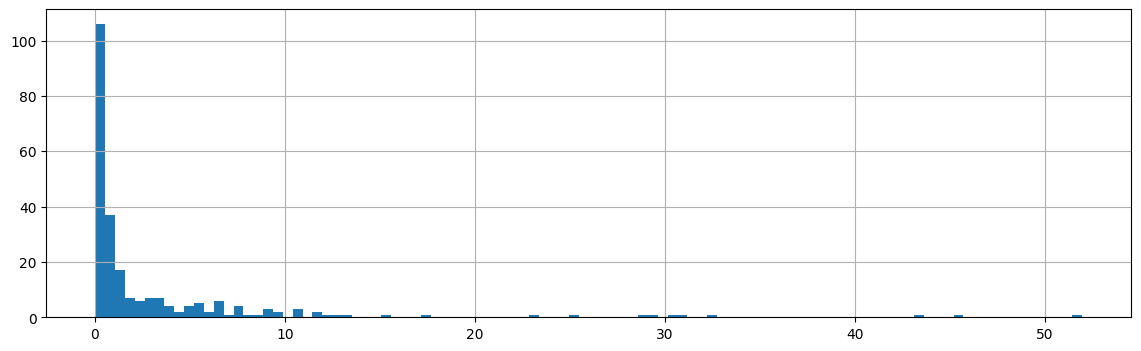

In [309]:
z1024['C1-RF/DIDP'].mean(),z1024['C1-RF/DIDP'].std()
z1024['C1-RF/DIDP'].hist(bins=100)
len(z1024[z1024['C1-RF/DIDP']<=1]),len(z1024[z1024['C1-RF/DIDP']>1])

# Slow ones

It appears that, among the slow benchmarks, only 27 of them (out of 100) take > 1 second for CODD whereas DIDP on those is ususally < 5s
Those are the interesting one to dig into.


In [308]:
zSlow =z1024[z1024['C3-RF/DIDP']>1]
with pd.option_context('display.max_rows', None,'display.max_columns',None):
    display(zSlow[zSlow['P(codd3_rf)'] >= 1.0])
print("How many:",len(zSlow[zSlow['P(codd3_rf)'] >= 1.0]))

,Bench,Width_x,O(codd3_xf),N(codd3_xf),P(codd3_xf),N(codd3_rf),P(codd3_rf),N(codd2_xf),P(codd2_xf),N(codd2_rf),P(codd2_rf),N(codd1_xf),P(codd1_xf),N(codd1_rf),P(codd1_rf),Opt_didp,nodes1_didp,nodes2_didp,Proof Time_didp,C3-XF/DIDP,C3-RF/DIDP,C2-XF/DIDP,C2-RF/DIDP,C1-XF/DIDP,C1-RF/DIDP
35,AFG/rbg021.2.tw,1024,4528.0,864,2.028,6,1.410,701,1.059,3,0.613,1114,0.991,3,0.481,4528.0,50667,65549,0.156465,12.961376,9.011607,6.768292,3.917812,6.333690,3.074172
38,AFG/rbg021.3.tw,1024,4528.0,6393,9.040,52,5.855,5467,5.909,15,2.479,10427,7.731,38,2.077,4528.0,93685,125981,0.308425,29.310194,18.983538,19.158621,8.037607,25.066052,6.734212
41,AFG/rbg021.4.tw,1024,4525.0,59196,149.896,879,129.208,54430,160.784,644,77.001,68882,230.776,886,61.704,4525.0,386024,562839,1.415505,105.895757,91.280481,113.587710,54.398244,163.034366,43.591502
68,AFG/rbg033a.tw,1024,2069.0,891,4.385,1,3.203,891,5.161,1,3.258,666,2.739,1,2.685,2069.0,27292,35709,0.173600,25.259271,18.450501,29.729327,18.767322,15.777684,15.466623
80,AFG/rbg038a.tw,1024,2480.0,4680,38.322,5,7.740,4707,38.056,5,7.902,3207,19.992,5,6.101,2480.0,37969,48908,0.209508,182.914477,36.943741,181.644834,37.716982,95.423679,29.120642
347,Dumas/n40w100.001.txt,1024,429.0,54181,122.734,43,4.164,41492,182.133,41,5.809,19539,31.045,48,3.053,429.0,124892,157583,0.848231,144.693998,4.909038,214.720876,6.848367,36.599680,3.599253
353,Dumas/n40w100.003.txt,1024,364.0,5804,16.214,5,1.177,5027,24.337,7,1.575,4967,14.249,19,1.060,364.0,46597,57914,0.329843,49.156668,3.568361,73.783509,4.774994,43.199294,3.213647
401,Dumas/n40w60.004.txt,1024,382.0,2337,20.800,34,20.231,2091,40.294,30,25.483,1259,8.700,36,14.666,382.0,44779,58027,0.477785,43.534211,42.343299,84.334976,53.335688,18.209021,30.695805
470,Dumas/n60w60.002.txt,1024,566.0,730,5.370,1,1.300,657,11.366,1,1.322,337,1.792,1,1.217,566.0,37471,46030,0.455804,11.781385,2.852104,24.936168,2.900371,3.931516,2.670008
488,Dumas/n60w80.003.txt,1024,550.0,669,54.863,290,63.427,648,251.192,1,250.234,320,13.457,1,13.929,550.0,99228,123736,1.319713,41.571913,48.061203,190.338335,189.612420,10.196913,10.554567


How many: 27


In [305]:
zSlow =z256[z256['C3-RF/DIDP']>1]
with pd.option_context('display.max_rows', None,'display.max_columns',None):
    display(zSlow[zSlow['P(codd3_rf)'] >= 1.0])
print("How many:",len(zSlow[zSlow['P(codd3_rf)'] >= 1.0]))

,Bench,Width_x,O(codd3_xf),N(codd3_xf),P(codd3_xf),N(codd3_rf),P(codd3_rf),N(codd2_xf),P(codd2_xf),N(codd2_rf),P(codd2_rf),N(codd1_xf),P(codd1_xf),N(codd1_rf),P(codd1_rf),Opt_didp,nodes1_didp,nodes2_didp,Proof Time_didp,C3-XF/DIDP,C3-RF/DIDP,C2-XF/DIDP,C2-RF/DIDP,C1-XF/DIDP,C1-RF/DIDP
10,AFG/rbg017.2.tw,256,852.0,7350,1.780,95,1.707,5379,1.063,59,0.823,7886,1.248,155,0.716,852.0,140148,213796,0.414247,4.296951,4.120728,2.566101,1.986736,3.012694,1.728437
22,AFG/rbg019b.tw,256,1866.0,53982,39.607,319,7.241,61095,101.139,493,7.464,45301,27.697,550,4.104,1866.0,18004,23778,0.060373,656.040990,119.938213,1675.242500,123.631932,458.766564,67.977686
34,AFG/rbg021.2.tw,256,4528.0,2720,1.657,103,3.236,2575,1.021,71,1.593,4863,1.248,183,1.376,4528.0,50667,65549,0.156465,10.590236,20.681958,6.525426,10.181199,7.976231,8.794306
37,AFG/rbg021.3.tw,256,4528.0,9010,7.776,567,17.496,8124,5.760,324,8.099,14882,7.087,848,6.904,4528.0,93685,125981,0.308425,25.211955,56.726898,18.675522,26.259210,22.978025,22.384688
64,AFG/rbg031a.tw,256,1863.0,4628,14.841,23,2.997,4614,16.652,23,3.671,2560,5.611,23,1.561,1863.0,12953,16728,0.067199,220.853082,44.599197,247.803080,54.629180,83.498864,23.229679
67,AFG/rbg033a.tw,256,2069.0,1073,11.310,199,16.039,1022,16.458,215,22.299,1801,6.984,253,6.147,2069.0,27292,35709,0.173600,65.149911,92.390753,94.804353,128.450739,40.230502,35.409063
202,Dumas/n150w20.003.txt,256,834.0,133,1.274,1,1.070,132,9.140,1,1.101,79,0.529,1,0.847,834.0,17427,20374,0.496299,2.566999,2.155957,18.416303,2.218419,1.065889,1.706631
253,Dumas/n200w20.005.txt,256,1020.0,278,6.618,1,2.637,262,106.384,1,2.527,173,2.140,1,2.060,1020.0,22630,26317,0.894975,7.394622,2.946452,118.868154,2.823543,2.391129,2.301741
400,Dumas/n40w60.004.txt,256,382.0,20755,181.054,3420,113.081,13042,283.298,3914,244.069,12189,59.886,4474,60.120,382.0,44779,58027,0.477785,378.944379,236.677507,592.940143,510.834202,125.340855,125.830614
406,Dumas/n40w80.001.txt,256,395.0,137,1.522,63,1.142,124,1.934,68,1.635,133,0.653,68,0.382,395.0,9765,12090,0.075233,20.230526,15.179540,25.706857,21.732529,8.679720,5.077570


How many: 34


In [306]:
zSlow =z128[z128['C3-RF/DIDP']>1]
with pd.option_context('display.max_rows', None,'display.max_columns',None):
    display(zSlow[zSlow['P(codd3_rf)'] >= 1.0])
print("How many:",len(zSlow[zSlow['P(codd3_rf)'] >= 1.0]))

,Bench,Width_x,O(codd3_xf),N(codd3_xf),P(codd3_xf),N(codd3_rf),P(codd3_rf),N(codd2_xf),P(codd2_xf),N(codd2_rf),P(codd2_rf),N(codd1_xf),P(codd1_xf),N(codd1_rf),P(codd1_rf),Opt_didp,nodes1_didp,nodes2_didp,Proof Time_didp,C3-XF/DIDP,C3-RF/DIDP,C2-XF/DIDP,C2-RF/DIDP,C1-XF/DIDP,C1-RF/DIDP
9,AFG/rbg017.2.tw,128,852.0,8239,1.911,145,1.953,6354,1.150,115,0.980,13182,2.345,287,0.729,852.0,140148,213796,0.414247,4.613188,4.714576,2.776120,2.365737,5.660871,1.759819
33,AFG/rbg021.2.tw,128,4528.0,3703,1.598,239,3.619,3663,1.171,167,1.764,8410,1.908,528,1.533,4528.0,50667,65549,0.156465,10.213155,23.129792,7.484108,11.274096,12.194430,9.797726
36,AFG/rbg021.3.tw,128,4528.0,10842,7.312,1432,20.697,10343,6.452,1010,11.370,19866,9.806,2573,10.151,4528.0,93685,125981,0.308425,23.707538,67.105430,20.919178,36.864702,31.793779,32.912365
63,AFG/rbg031a.tw,128,1863.0,12721,101.349,3306,85.548,12231,120.790,3607,112.700,14307,24.236,4258,19.493,1863.0,12953,16728,0.067199,1508.202882,1273.063771,1797.509853,1677.120295,360.662710,290.080798
195,Dumas/n150w20.001.txt,128,925.0,138,6.249,14,1.048,125,45.644,14,8.162,49,0.306,14,0.098,925.0,10335,11321,0.269398,23.196168,3.890156,169.429650,30.297187,1.135866,0.363774
405,Dumas/n40w80.001.txt,128,395.0,20293,10.786,99,2.138,18721,14.127,99,2.560,8624,4.369,101,1.407,395.0,9765,12090,0.075233,143.368234,28.418439,187.777030,34.027691,58.073041,18.701938
408,Dumas/n40w80.002.txt,128,431.0,5194,5.063,125,2.730,3382,8.503,179,5.498,3051,2.292,521,1.880,431.0,63461,74114,0.600776,8.427436,4.544124,14.153365,9.151500,3.815067,3.129287
474,Dumas/n60w60.004.txt,128,571.0,8343,35.113,516,8.106,5489,107.615,892,26.399,5287,7.869,1366,4.441,571.0,19582,22965,0.287847,121.984772,28.160754,373.861283,91.711787,27.337401,15.428313
633,GendreauDumasExtended/n20w120.002.txt,128,218.0,6812,2.206,192,1.194,4618,1.730,200,1.326,3879,1.078,260,0.861,218.0,25678,31703,0.091515,24.105206,13.046970,18.903902,14.489349,11.779425,9.408242
642,GendreauDumasExtended/n20w120.005.txt,128,240.0,6310,1.872,112,1.101,6637,2.537,251,2.009,7743,1.538,393,1.392,240.0,16833,22837,0.059958,31.222009,18.362944,42.313161,33.506953,25.651415,23.216366


How many: 27


# compute average speedup across various widths

In [1016]:
def average_speedup(L, R, w, exclude_below_L=None):
    global final
    L_times = final[f'Proof Time{suffixes[L]}']
    R_times = final[f'Proof Time{suffixes[R]}']
    L_times = L_times[(final[f'Proof Time{suffixes[L]}'] != 'T.O.') & (final[f'Proof Time{suffixes[R]}'] != 'T.O.') & (final['Width']==w)]
    R_times = R_times[(final[f'Proof Time{suffixes[L]}'] != 'T.O.') & (final[f'Proof Time{suffixes[R]}'] != 'T.O.') & (final['Width']==w)]

    if exclude_below_L is not None:
        R_times = R_times[L_times >= exclude_below_L]        
        L_times = L_times[L_times >= exclude_below_L]

    speedup = R_times / L_times
    # print(speedup)
    speedup = speedup.astype(float).replace(np.inf, np.nan).dropna()

    avg = np.average(speedup)
    if avg >= 1:
        print(f'{suffixes[L]} is {avg:.2f}x faster than {suffixes[R]}  ')
    else:
        print(f'{suffixes[L]} is {avg:.2f}x faster than {suffixes[R]} ({1/avg:.2f}x slower)')
    #print(f'                = {avg:.2f}')
    # else:
    #     print(f'average slowdown = {1/avg}')
    #     print(f'                 = {1/avg:.2f}')

In [1017]:
for w in set(final['Width']):
    print(f'w={w}')
    average_speedup(0,1,w)
    average_speedup(0,2,w)
    average_speedup(0,3,w)
    print(f'ignoring {suffixes[L]} < 1s')
    average_speedup(0,1,w,exclude_below_L=1)
    average_speedup(0,2,w,exclude_below_L=1)
    average_speedup(0,3,w,exclude_below_L=1)
    print()

w=8
_codd_dl is 1.56x faster than _codd_cl  
_codd_dl is 0.20x faster than _codd (5.08x slower)
_codd_dl is 1.03x faster than _didp  
ignoring _codd_dl < 1s
_codd_dl is 1.25x faster than _codd_cl  
_codd_dl is 0.09x faster than _codd (10.68x slower)
_codd_dl is 0.07x faster than _didp (13.58x slower)

w=1024
_codd_dl is 1.12x faster than _codd_cl  
_codd_dl is 0.11x faster than _codd (9.49x slower)
_codd_dl is 4.20x faster than _didp  
ignoring _codd_dl < 1s
_codd_dl is 0.05x faster than _codd_cl (19.05x slower)
_codd_dl is 0.03x faster than _codd (38.87x slower)
_codd_dl is 0.04x faster than _didp (25.88x slower)

w=128
_codd_dl is 1.83x faster than _codd_cl  
_codd_dl is 0.10x faster than _codd (10.33x slower)
_codd_dl is 3.93x faster than _didp  
ignoring _codd_dl < 1s
_codd_dl is 0.04x faster than _codd_cl (25.14x slower)
_codd_dl is 0.03x faster than _codd (35.01x slower)
_codd_dl is 0.02x faster than _didp (47.48x slower)



# how many instances can each solver solve, at each width?

In [171]:
for suffix in suffixes:
    print(f'# where {suffix} solved within timeout: ')
    print('\t'.join(f'w={w}' for w in set(final['Width'])))
    for w in set(final['Width']):
        print(f'{len(final[ (final[f"Proof Time{suffix}"]!="T.O.") & (final["Width"]==w) ])}', end='\t')
    print()

# where _codd3_xf solved within timeout: 


KeyError: 'Width'

# how many instances where one solver times out and another solves

In [163]:
def TO_solves(L,R):
    X_TO = final[(final[f'Proof Time{suffixes[L]}']=='T.O.') & (final[f'Proof Time{suffixes[R]}']!='T.O.') & (final[f'Proof Time{suffixes[R]}'].notna()) & (final[f'Proof Time{suffixes[L]}'].notna())]
    R_TO = final[(final[f'Proof Time{suffixes[L]}']!='T.O.') & (final[f'Proof Time{suffixes[R]}']=='T.O.') & (final[f'Proof Time{suffixes[R]}'].notna()) & (final[f'Proof Time{suffixes[L]}'].notna())]
    print(f'# where {suffixes[L]} TOs, {suffixes[R]} solves: {len(X_TO)}')
    print(f'# where {suffixes[R]} TOs, {suffixes[L]} solves: {len(R_TO)}\n')
TO_solves(0,1)
TO_solves(1,2)
TO_solves(0,2)
# TO_solves(1,3)

# where _codd3_xf TOs, _codd3_rf solves: 41
# where _codd3_rf TOs, _codd3_xf solves: 8

# where _codd3_rf TOs, _codd2_xf solves: 1
# where _codd2_xf TOs, _codd3_rf solves: 57

# where _codd3_xf TOs, _codd2_xf solves: 2
# where _codd2_xf TOs, _codd3_xf solves: 25



In [1020]:
final = final.dropna() #need NaN rows to compute above, but don't want for plots

# If a row appears in any of the following dataframes, two solvers gave different opt values

In [162]:
print(f'rows where Opt{suffixes[L]} and Opt{suffixes[R]} disagree:')
final[final[f'Opt{suffixes[L]}'].notna() & final[f'Opt{suffixes[R]}'].notna() & (final[f'Opt{suffixes[L]}'] != final[f'Opt{suffixes[R]}'])]

rows where Opt_codd3_xf and Opt_codd3_rf disagree:


,Bench,Width_x,Opt_codd3_xf,nodes1_codd3_xf,nodes2_codd3_xf,P_codd3_xf,D_codd3_xf,Opt Time_codd3_xf,Proof Time_codd3_xf,Opt_codd3_rf,...,Width_y,Opt_didp_x,nodes1_didp_x,nodes2_didp_x,Proof Time_didp_x,Width,Opt_didp_y,nodes1_didp_y,nodes2_didp_y,Proof Time_didp_y


In [90]:
R=2
print(f'rows where Opt{suffixes[L]} and Opt{suffixes[R]} disagree:')
final[final[f'Opt{suffixes[L]}'].notna() & final[f'Opt{suffixes[R]}'].notna() & (final[f'Opt{suffixes[L]}'] != final[f'Opt{suffixes[R]}'])]

rows where Opt_codd3_xf and Opt_codd2_xf disagree:


,Bench,Width,Opt_codd3_xf,nodes1_codd3_xf,nodes2_codd3_xf,P_codd3_xf,D_codd3_xf,Opt Time_codd3_xf,Proof Time_codd3_xf,Opt_codd3_rf,...,D_codd1_xf,Opt Time_codd1_xf,Proof Time_codd1_xf,Opt_codd1_rf,nodes1_codd1_rf,nodes2_codd1_rf,P_codd1_rf,D_codd1_rf,Opt Time_codd1_rf,Proof Time_codd1_rf


In [91]:
R=3
print(f'rows where Opt{suffixes[L]} and Opt{suffixes[R]} disagree:')
final[final[f'Opt{suffixes[L]}'].notna() & final[f'Opt{suffixes[R]}'].notna() & (final[f'Opt{suffixes[L]}'] != final[f'Opt{suffixes[R]}'])]

rows where Opt_codd3_xf and Opt_codd2_rf disagree:


,Bench,Width,Opt_codd3_xf,nodes1_codd3_xf,nodes2_codd3_xf,P_codd3_xf,D_codd3_xf,Opt Time_codd3_xf,Proof Time_codd3_xf,Opt_codd3_rf,...,D_codd1_xf,Opt Time_codd1_xf,Proof Time_codd1_xf,Opt_codd1_rf,nodes1_codd1_rf,nodes2_codd1_rf,P_codd1_rf,D_codd1_rf,Opt Time_codd1_rf,Proof Time_codd1_rf


In [1024]:
codd_dl_slower = final[final["Proof Time_codd_dl"] > final["Proof Time_didp"]][["Bench", "Width", "Proof Time_codd_dl", "Proof Time_didp"]]
# codd_dl_slower.to_csv('codd_dl_slower.csv')
codd_dl_slower

,Bench,Width,Proof Time_codd_dl,Proof Time_didp
0,AFG/rbg010a.tw,8,0.003,0.001703
6,AFG/rbg016b.tw,8,0.361,0.029153
7,AFG/rbg016b.tw,128,0.276,0.029153
8,AFG/rbg016b.tw,1024,0.069,0.029153
10,AFG/rbg017.2.tw,128,11.931,0.486632
11,AFG/rbg017.2.tw,1024,12.593,0.486632
114,Langevin/N40ft403.dat,8,0.022,0.008945
123,Langevin/N40ft406.dat,8,0.006,0.004015
168,Langevin/N60ft301.dat,8,0.014,0.00977
177,Langevin/N60ft304.dat,8,0.014,0.009646


# plots

In [160]:
plt.rcParams['figure.figsize'] = [14,4]
def cum_plot(df, column, log=False, ep=1e-6, sort_by=0, title='', find_peaks=None, peak_time=1):
    s = [suffix for suffix in suffixes if (f'{column}{suffix}' in df.columns)]
    for suffix in s:
        df = df[df[f'{column}{suffix}'] != 'T.O.']
    if sort_by is not None: df = df.sort_values(by=f'{column}{suffixes[sort_by]}')
    #print(df['Bench'])

    _,[ax1,ax2] = plt.subplots(1,2)

    Ys = np.array([np.cumsum(df[f'{column}{suffix}']) for suffix in s])
    if log:
        #Ys = np.array([[y+ep if y else y for y in Ys[i,:]] for i in range(len(Ys))])
        Ys += ep
        ax1.set_yscale('log')
    X = np.arange(Ys.shape[1])

    ax1.plot(X, Ys.T, label=[f'{column}{suffix}' for suffix in s])
    ax1.set_xlabel('# of Experiments')
    ax1.set_ylabel(f'Cumulative {column} (log)' if log else f'Cumulative {column}')
    ax1.set_title(title)
    ax1.legend()
    
    Ys = np.array([df[f'{column}{suffix}'] for suffix in s])
    if log:
        #Ys = np.array([[y+ep if y else y for y in Ys[i,:]] for i in range(len(Ys))])
        Ys += ep
        ax2.set_yscale('log')
    X = np.arange(Ys.shape[1])

    ax2.plot(X, Ys.T, label=[f'{column}{suffix}' for suffix in s])

    if find_peaks is not None:
        for i in find_peaks:
            Y = Ys[i]
            dY = np.diff(Y)
            peaks = np.where((dY[:-1] > 0) & (dY[1:] < 0) & (np.abs(Y[1:-1]-Ys[sort_by][1:-1]) > peak_time))[0] + 1 
            ax2.scatter(X[peaks],Y[peaks],marker='x')
            bad_instances = df.iloc[peaks][['Bench', f'Proof Time{suffixes[i]}']]
            if len(bad_instances) > 0:
                print(bad_instances)

    ax2.set_xlabel('# of Experiments')
    ax2.set_ylabel(f'{column} (log)' if log else f'{column}')
    ax2.set_title(title)
    ax2.legend()
    plt.show()

# proof time vs # of expiriemnts, for every width
plots on the left are cumulative, plots on the right are not

x's mark instances that take longer than a second and are local maxima. These instances are also printed

                                      Bench Proof Time_codd3_xf
654   GendreauDumasExtended/n20w140.004.txt               5.199
655   GendreauDumasExtended/n20w140.004.txt                5.59
684   GendreauDumasExtended/n20w180.004.txt               4.253
37                          AFG/rbg021.3.tw               7.776
38                          AFG/rbg021.3.tw                9.04
685   GendreauDumasExtended/n20w180.004.txt               4.596
1376       SolomonPotvinBengio/rc_206.3.txt               3.252
662   GendreauDumasExtended/n20w160.001.txt               4.988
409                    Dumas/n40w80.002.txt               3.638
408                    Dumas/n40w80.002.txt               5.063
470                    Dumas/n60w60.002.txt                5.37
661   GendreauDumasExtended/n20w160.001.txt              12.196
669   GendreauDumasExtended/n20w160.004.txt              14.616
694   GendreauDumasExtended/n20w200.002.txt              17.756
693   GendreauDumasExtended/n20w200.002.

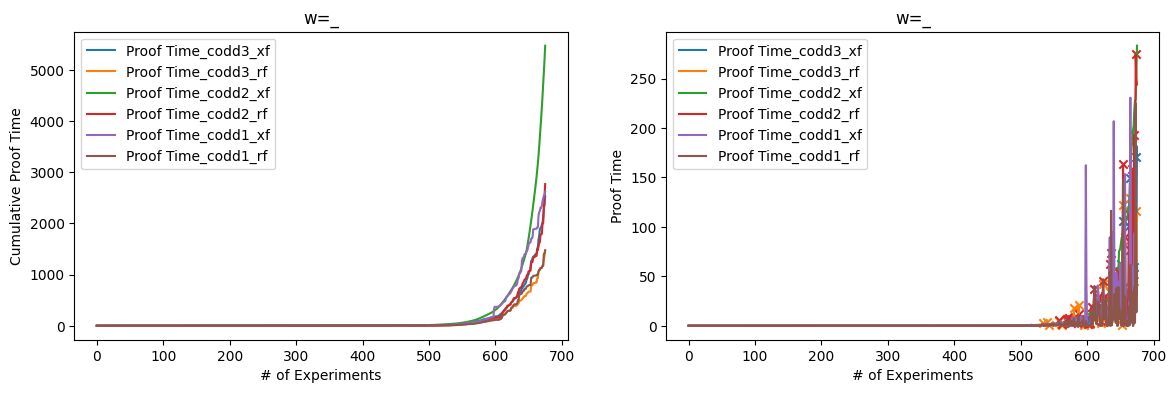

In [161]:
for w in set(final['Width']):
    cum_plot(final[final['Width']==w], 'Proof Time', sort_by=2, find_peaks=[0,1,2,3], peak_time=1, title=f"w={w}")

# proof time vs # of expiriemnts, for every width (log scale)
plots on the left are cumulative, plots on the right are not

x's mark instances that take longer than a second and are local maxima. These instances are also printed

                                     Bench Proof Time_codd3_xf
654  GendreauDumasExtended/n20w140.004.txt               5.199
684  GendreauDumasExtended/n20w180.004.txt               4.253
408                   Dumas/n40w80.002.txt               5.063
693  GendreauDumasExtended/n20w200.002.txt              21.863
699  GendreauDumasExtended/n20w200.004.txt              22.763
690  GendreauDumasExtended/n20w200.001.txt              33.365
687  GendreauDumasExtended/n20w180.005.txt              22.341
411                   Dumas/n40w80.003.txt              85.206
                                      Bench Proof Time_codd3_rf
33                          AFG/rbg021.2.tw               3.619
675   GendreauDumasExtended/n20w180.001.txt               4.683
654   GendreauDumasExtended/n20w140.004.txt                6.89
36                          AFG/rbg021.3.tw              20.697
1260                  SolomonPesant/rc203.2               3.171
693   GendreauDumasExtended/n20w200.002.txt      

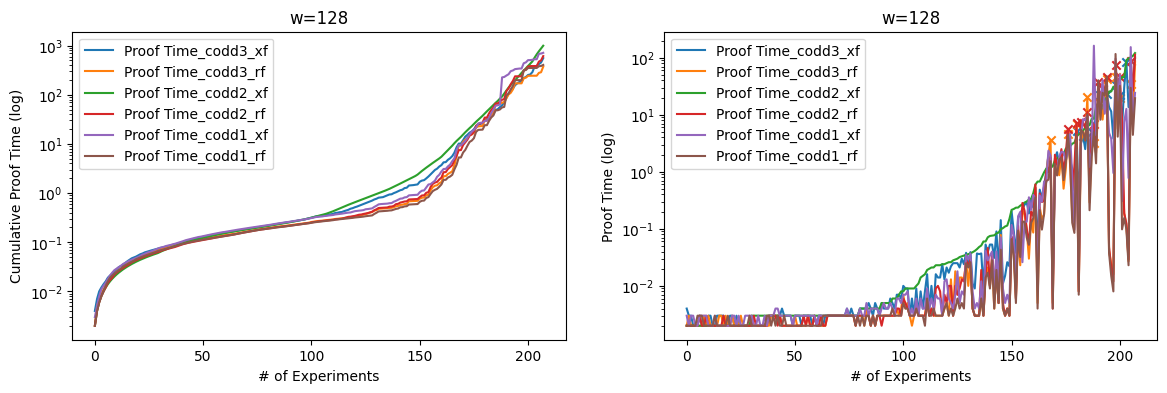

                                      Bench Proof Time_codd3_xf
655   GendreauDumasExtended/n20w140.004.txt                5.59
37                          AFG/rbg021.3.tw               7.776
1261                  SolomonPesant/rc203.2               4.805
670   GendreauDumasExtended/n20w160.004.txt              12.743
694   GendreauDumasExtended/n20w200.002.txt              17.756
457                    Dumas/n60w40.003.txt              18.436
700   GendreauDumasExtended/n20w200.004.txt              28.003
355                   Dumas/n40w100.004.txt              62.624
697   GendreauDumasExtended/n20w200.003.txt             105.481
523                    Dumas/n80w40.005.txt              25.471
                                      Bench Proof Time_codd3_rf
34                          AFG/rbg021.2.tw               3.236
643   GendreauDumasExtended/n20w120.005.txt               0.342
655   GendreauDumasExtended/n20w140.004.txt               3.408
37                          AFG/rbg021.3

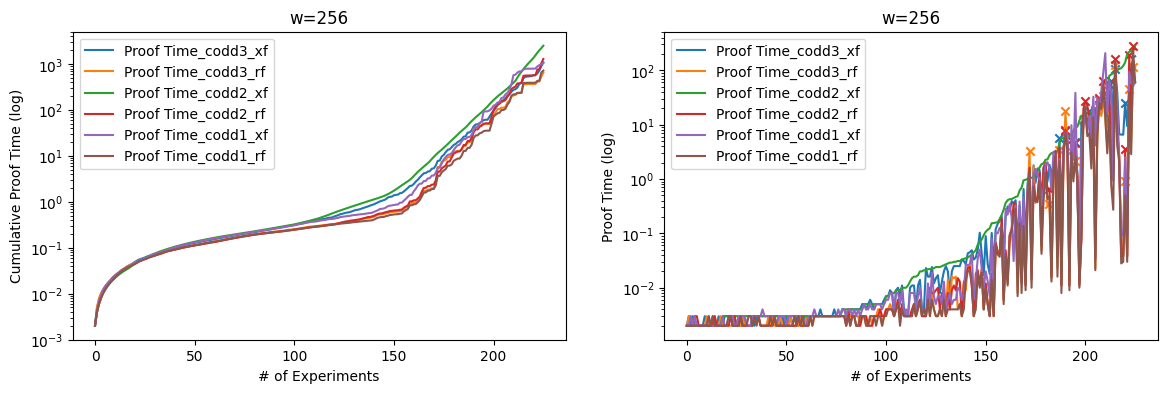

                                      Bench Proof Time_codd3_xf
38                          AFG/rbg021.3.tw                9.04
662   GendreauDumasExtended/n20w160.001.txt               4.988
470                    Dumas/n60w60.002.txt                5.37
701   GendreauDumasExtended/n20w200.004.txt              17.465
1253                  SolomonPesant/rc202.3              12.123
353                   Dumas/n40w100.003.txt              16.214
698   GendreauDumasExtended/n20w200.003.txt              50.795
1334       SolomonPotvinBengio/rc_202.4.txt              53.682
41                          AFG/rbg021.4.tw             149.896
347                   Dumas/n40w100.001.txt             122.734
494                    Dumas/n60w80.005.txt              59.055
                                      Bench Proof Time_codd3_rf
1244                  SolomonPesant/rc202.0               0.745
656   GendreauDumasExtended/n20w140.004.txt               0.846
68                           AFG/rbg033a

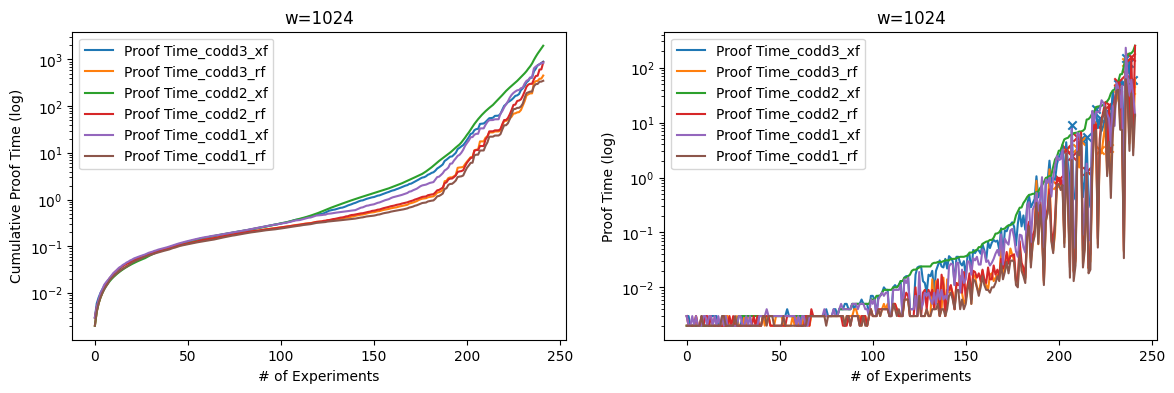

In [94]:
for w in set(final['Width']):
    cum_plot(final[final['Width']==w], 'Proof Time', sort_by=2, find_peaks=[0,1,2,3], peak_time=1, title=f"w={w}", log=True)

# nodes vs # of expiriemnts, for every width
plots on the left are cumulative, plots on the right are not

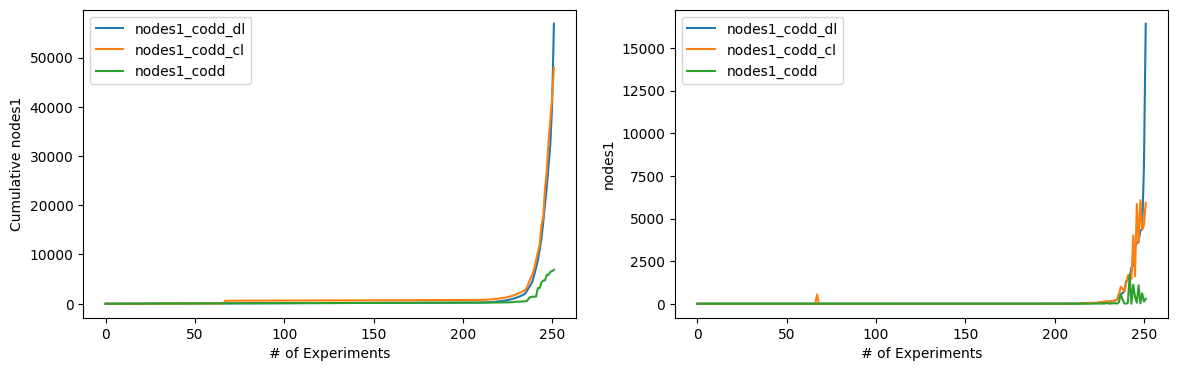

In [1028]:
cum_plot(final, 'nodes1')

# nodes vs # of expiriemnts, for every width (log scale)
plots on the left are cumulative, plots on the right are not

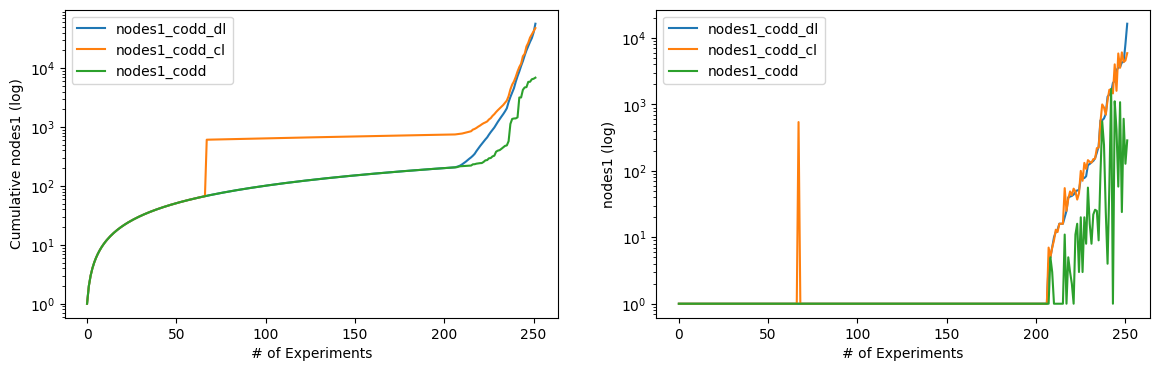

In [1029]:
cum_plot(final, 'nodes1', log=True)

# Playing around, no more analysis

In [1030]:
def valid_benches(exp, prefix='../data/tsptw'):
    return ' '.join([f'{prefix}/{x}' for x in exp1['Bench'].drop_duplicates()])

In [1031]:
exp = experiment_to_df_tsptw('tsptw_TO_1000s_fixlocal/tsptw_RFL_1000', scale_opt=10000.0); exp['Bench'] = exp['Bench'].str.split('/').str[-2:].str.join('/')
valid_benches(exp, prefix='./resources/tsptw')

'./resources/tsptw/AFG/rbg010a.tw ./resources/tsptw/AFG/rbg016a.tw ./resources/tsptw/AFG/rbg016b.tw ./resources/tsptw/AFG/rbg017.2.tw ./resources/tsptw/Dumas/n100w20.001.txt ./resources/tsptw/GendreauDumasExtended/n100w100.001.txt ./resources/tsptw/Langevin/N20ft301.dat ./resources/tsptw/Langevin/N20ft302.dat ./resources/tsptw/Langevin/N20ft303.dat ./resources/tsptw/Langevin/N20ft304.dat ./resources/tsptw/Langevin/N20ft305.dat ./resources/tsptw/Langevin/N20ft306.dat ./resources/tsptw/Langevin/N20ft307.dat ./resources/tsptw/Langevin/N20ft308.dat ./resources/tsptw/Langevin/N20ft309.dat ./resources/tsptw/Langevin/N20ft310.dat ./resources/tsptw/Langevin/N20ft401.dat ./resources/tsptw/Langevin/N20ft402.dat ./resources/tsptw/Langevin/N20ft403.dat ./resources/tsptw/Langevin/N20ft404.dat ./resources/tsptw/Langevin/N20ft405.dat ./resources/tsptw/Langevin/N20ft406.dat ./resources/tsptw/Langevin/N20ft407.dat ./resources/tsptw/Langevin/N20ft408.dat ./resources/tsptw/Langevin/N20ft409.dat ./resourc

In [1032]:
valid_benches(exp1)

'../data/tsptw/AFG/rbg010a.tw ../data/tsptw/AFG/rbg016a.tw ../data/tsptw/AFG/rbg016b.tw ../data/tsptw/AFG/rbg017.2.tw ../data/tsptw/Dumas/n100w20.001.txt ../data/tsptw/GendreauDumasExtended/n100w100.001.txt ../data/tsptw/Langevin/N20ft301.dat ../data/tsptw/Langevin/N20ft302.dat ../data/tsptw/Langevin/N20ft303.dat ../data/tsptw/Langevin/N20ft304.dat ../data/tsptw/Langevin/N20ft305.dat ../data/tsptw/Langevin/N20ft306.dat ../data/tsptw/Langevin/N20ft307.dat ../data/tsptw/Langevin/N20ft308.dat ../data/tsptw/Langevin/N20ft309.dat ../data/tsptw/Langevin/N20ft310.dat ../data/tsptw/Langevin/N20ft401.dat ../data/tsptw/Langevin/N20ft402.dat ../data/tsptw/Langevin/N20ft403.dat ../data/tsptw/Langevin/N20ft404.dat ../data/tsptw/Langevin/N20ft405.dat ../data/tsptw/Langevin/N20ft406.dat ../data/tsptw/Langevin/N20ft407.dat ../data/tsptw/Langevin/N20ft408.dat ../data/tsptw/Langevin/N20ft409.dat ../data/tsptw/Langevin/N20ft410.dat ../data/tsptw/Langevin/N40ft201.dat ../data/tsptw/Langevin/N40ft202.dat .

In [1033]:
final.head(20)

,Bench,Width,Opt_codd_dl,nodes1_codd_dl,nodes2_codd_dl,P_codd_dl,D_codd_dl,Opt Time_codd_dl,Proof Time_codd_dl,Opt_codd_cl,...,Proof Time_codd_cl,Opt_codd,nodes1_codd,nodes2_codd,P_codd,D_codd,Opt Time_codd,Proof Time_codd,Proof Time_didp,Opt_didp
0,AFG/rbg010a.tw,8,671.0,155,155,1,4,0.0,0.003,671.0,...,0.006,671.0,26,26,2,0,0.001,0.004,0.001703,671.0
1,AFG/rbg010a.tw,128,671.0,1,1,0,0,0.0,0.0,671.0,...,0.0,671.0,1,1,0,0,0.001,0.001,0.001703,671.0
2,AFG/rbg010a.tw,1024,671.0,1,1,0,0,0.0,0.0,671.0,...,0.0,671.0,1,1,0,0,0.0,0.0,0.001703,671.0
3,AFG/rbg016a.tw,8,938.0,20,20,0,0,0.0,0.002,938.0,...,0.003,938.0,11,11,0,0,0.0,0.002,0.003732,938.0
4,AFG/rbg016a.tw,128,938.0,1,1,0,0,0.0,0.001,938.0,...,0.001,938.0,1,1,0,0,0.001,0.001,0.003732,938.0
5,AFG/rbg016a.tw,1024,938.0,1,1,0,0,0.0,0.001,938.0,...,0.001,938.0,1,1,0,0,0.001,0.001,0.003732,938.0
6,AFG/rbg016b.tw,8,1304.0,3656,3677,465,1544,0.121,0.361,1304.0,...,0.258,1304.0,1082,1082,458,261,0.062,0.114,0.029153,1304.0
7,AFG/rbg016b.tw,128,1304.0,724,724,129,303,0.01,0.276,1304.0,...,0.092,1304.0,24,24,0,144,0.002,0.045,0.029153,1304.0
8,AFG/rbg016b.tw,1024,1304.0,1,1,0,0,0.069,0.069,1304.0,...,0.065,1304.0,1,1,0,0,0.005,0.005,0.029153,1304.0
10,AFG/rbg017.2.tw,128,852.0,16430,16430,1648,7610,0.013,11.931,852.0,...,0.926,852.0,288,288,0,447,0.001,0.661,0.486632,852.0


In [1034]:
numeric = final[final['Proof Time_RF'] != 'T.O.']
#numeric[numeric['Proof Time_XF'] >= 100]
numeric.sort_values(by='Proof Time_RF', ascending=False).head(4)

KeyError: 'Proof Time_RF'